In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([0.2, 0.0, 0.02])

# train_data = "../data/output_old.npz"
# valid_data = "../data/output_valid.npz"

# train_data = "../data/combined_output_new_train.npz"
# valid_data = "../data/combined_output_new_test.npz"

# train_file = "training_data.npz"
# valid_file = "validation_data.npz"
# # convert to direct-BC format
# convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
# convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


# train_file = "../experiment_data/train_dataset.npz"
# valid_file = "../experiment_data/test_dataset.npz"

train_file = "../experiment_data/combined_dataset.npz"
valid_file = "../experiment_data/combined_dataset.npz"


In [3]:
from properties import Properties

properties = Properties(
    length = 0.2,
    r0 = 0.005,
    axs = None,
    jxs = None,
    ixs1 = None,
    ixs2 = None,
    density = 800.0,
    E = 1e6,
    N = 3,
    # start = jax.numpy.array([0, 0, 0]),
    # end = jax.numpy.array([0.266166, 0., 0.01240256]),
    mass = 0.3
)

params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(0),
    hidden=(10,),
    which_case="MLP",
    corr_factor=1,
    input_mode="raw",
    zero_reference=True,
    activation="tanh"
)

model_cls = CholeskyPlusStiffnessNN

In [4]:
from util import train_model
from util_energy_plots import EnergyLandscapeSpec, make_energy_snapshot_fn

spec = EnergyLandscapeSpec(
    strain_x_idx=0,
    strain_y_idx=3,
    triplet_idx=0,
    contour_style="lines",
    n_levels=20,
    show_colorbar=False,
    fixed_mode="first_path_point",
    strain_labels=["e0", "e1", "e2", "eb0", "eb1"],
    title="Energy contour during training",
    # better to fix these once known:
    xlim=(-4, 4.0),
    ylim=(0.0, 4.0),
)

snapshot_fn = make_energy_snapshot_fn(
    spec=spec,
    save_dir="energy_snapshots_LLT_stiff_MLP_positive_correction",
    use_valid=True,
    traj_idx=0,
    max_dlambda=5e-3,
    iters=5,
    ls_steps=10,
)

model, train_hist, valid_hist = train_model(
    properties=properties,
    model_cls=model_cls,
    params=params,
    train_file=train_file,
    valid_file=valid_file,
    n_epochs=1000,
    lr=5e-2,
    snapshot_fn=snapshot_fn,
    snapshot_every=200,
    valid_every=10,
    max_dlambda=5e-3,
    iters=5,
    ls_steps=10,
)

Epoch 000 | Train: 2.099e-04 | Valid: 1.008e-04
Epoch 010 | Train: 3.635e-05 | Valid: 3.634e-05
Epoch 020 | Train: 2.062e-05 | Valid: 2.101e-05
Epoch 030 | Train: 1.485e-05 | Valid: 1.521e-05
Epoch 040 | Train: 1.289e-05 | Valid: 1.263e-05
Epoch 050 | Train: 9.318e-06 | Valid: 8.883e-06
Epoch 060 | Train: 5.967e-06 | Valid: 5.701e-06
Epoch 070 | Train: 4.167e-06 | Valid: 4.063e-06
Epoch 080 | Train: 3.605e-06 | Valid: 3.579e-06
Epoch 090 | Train: 3.193e-06 | Valid: 3.149e-06
Epoch 100 | Train: 2.881e-06 | Valid: 2.856e-06
Epoch 110 | Train: 2.611e-06 | Valid: 2.587e-06
Epoch 120 | Train: 2.418e-06 | Valid: 2.402e-06
Epoch 130 | Train: 2.282e-06 | Valid: 2.273e-06
Epoch 140 | Train: 2.215e-06 | Valid: 2.211e-06
Epoch 150 | Train: 2.180e-06 | Valid: 2.177e-06
Epoch 160 | Train: 2.152e-06 | Valid: 2.149e-06
Epoch 170 | Train: 2.127e-06 | Valid: 2.125e-06
Epoch 180 | Train: 2.106e-06 | Valid: 2.104e-06
Epoch 190 | Train: 2.087e-06 | Valid: 2.085e-06
Epoch 200 | Train: 2.069e-06 | Valid: 2.

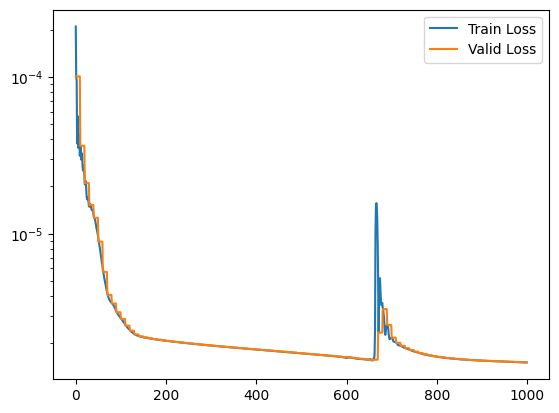

In [5]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_hist, dtype=float).reshape(-1)
valid_np = np.asarray(valid_hist, dtype=float).reshape(-1)

# print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [6]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
pred = predict(model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

In [7]:
animate(pred[0])


In [8]:

animate(valid.qs[0])

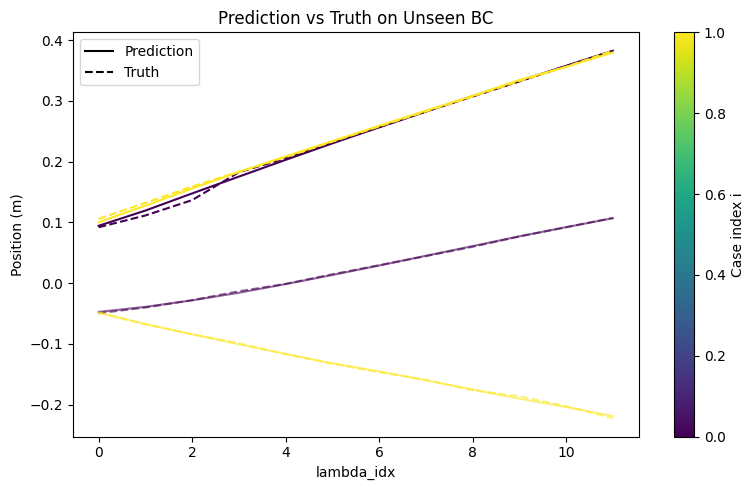

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

In [10]:
train = Dataset.load(train_file)
pred = predict(model, base, aux, train.idx_b, train.xb, train.lambdas)

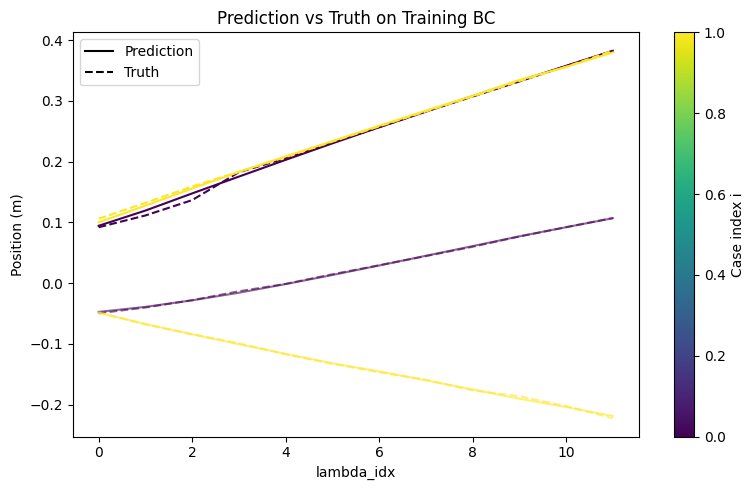

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(train.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(train.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Training BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()